In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
PHySICAL_PREDICTORS = ["phi_d", "phi_e"]   
TARGET_INT = ["theta", "x", "y"]       
TARGET = ["dtheta", "dx", "dy"]       
TIME_STEPS = 3
TS = 0.07
TITLES = [
    "ZZx1",  # Train
    "ZZx2",  # Val
    "ZZxReto", # Test
    "ZZy1", # Test
    "ZZy2", # Test
    "LSG-1", # Test
    "LSG-2", # Test
    "ZZx1-inv", # Test
    "zzx2-inv2", # Test
    "semiCirc", # Test
]
Datasets = []
for title in TITLES:
    df = pd.read_excel("./../../00-Data/SavgolDatasets.xlsx", sheet_name=title)
    Datasets.append(df)



In [10]:
import matplotlib.pyplot as plt

R = 0.0328
L = 0.0615
dt = 0.07

def CinematicModel(phi_d, phi_e, theta):
    dtheta_cin = (R/(2*L)) * (phi_d - phi_e)
    dx_cin = (R/2) * np.cos(theta) * (phi_d + phi_e)
    dy_cin = (R/2) * np.sin(theta) * (phi_d + phi_e)
    return [dtheta_cin, dx_cin, dy_cin]

def NumericalIntegration(Dataset, dq):
    
    init_vals = np.array([
        Dataset["theta"].iloc[0],
        Dataset["x"].iloc[0],
        Dataset["y"].iloc[0]
    ]) 
    
    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    x_cin     = init_vals[1] + np.cumsum(dq[1] * dt)
    y_cin     = init_vals[2] + np.cumsum(dq[2] * dt)
    return [theta_cin, x_cin, y_cin]
 
def PlotOut(ax, title, target_name, y_true, y_spline, y_cin):

    # 🔹 pega menor tamanho comum
    n = min(len(y_true), len(y_spline), len(y_cin))

    # 🔹 corta tudo igual
    y_true   = y_true[:n]
    y_spline = y_spline[:n]
    y_cin    = y_cin[:n]

    # 🔹 tempo consistente
    time = (np.arange(n).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_spline, linestyle='--', linewidth=1.5, label='Valores Filtrados')
    ax.plot(time, y_cin, linestyle=':', linewidth=1.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)

In [11]:
import pandas as pd
import numpy as np
from itertools import product

df_x_all = pd.read_excel("../x-otm/resultados_comparacao-otm.xlsx", sheet_name=None)
df_y_all = pd.read_excel("../y_otm/resultados_comparacao-otm.xlsx", sheet_name=None)

# 🔹 pegar colunas (assume iguais em todos)
sample_dfx = list(df_x_all.values())[0]
sample_dfy = list(df_y_all.values())[0]

cols_x = [c for c in sample_dfx.columns if "x_pred_" in c or c == "x_ens"]
cols_y = [c for c in sample_dfy.columns if "y_pred_" in c or c == "y_ens"]

results = []

# 🔹 testar TODAS combinações globalmente
for col_x, col_y in product(cols_x, cols_y):

    erros_all = []

    for title in TITLES:

        dfx = df_x_all[title]
        dfy = df_y_all[title]

        x_real = dfx["x_real"].values
        y_real = dfy["y_real"].values

        x_pred = dfx[col_x].values
        y_pred = dfy[col_y].values
        
        min_len = min(len(x_real), len(x_pred), len(y_real), len(y_pred))

        x_real = x_real[:min_len]
        y_real = y_real[:min_len]
        x_pred = x_pred[:min_len]
        y_pred = y_pred[:min_len]

        erro = np.sqrt((x_real - x_pred)**2 + (y_real - y_pred)**2)
        erros_all.append(np.mean(erro))

    erro_global = np.mean(erros_all)

    results.append({
        "x_model": col_x,
        "y_model": col_y,
        "erro_global": erro_global
    })

df_rank = pd.DataFrame(results).sort_values("erro_global")

# 🔹 TOP 3
top3 = df_rank.head(10)

print(top3)

# 🔹 salvar
top3.to_excel("top3_combinacoes_gerais.xlsx", index=False)

                                           x_model  \
20  x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416   
18  x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416   
23  x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416   
19  x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416   
22  x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416   
21  x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416   
24   x_pred_model_arch7_r0.01_Ld0.3_Lp0.7_seed9180   
6    x_pred_model_arch37_r0.9_Ld0.5_Lp0.5_seed5014   
8    x_pred_model_arch37_r0.9_Ld0.5_Lp0.5_seed5014   
11   x_pred_model_arch37_r0.9_Ld0.5_Lp0.5_seed5014   

                                           y_model  erro_global  
20   y_pred_model_arch21_r0.9_Ld0.5_Lp0.5_seed5011     0.543727  
18  y_pred_model_arch17_r0.01_Ld0.5_Lp0.5_seed6686     0.547339  
23                                           y_ens     0.553313  
19    y_pred_model_arch79_r0.9_Ld0.5_Lp0.5_seed922     0.560404  
22   y_pred_model_arch94_r0.9_Ld0.3_Lp0.7_seed1932     0.562985  
21   y_pr

In [12]:
display(top3)

,x_model,y_model,erro_global
20,x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416,y_pred_model_arch21_r0.9_Ld0.5_Lp0.5_seed5011,0.543727
18,x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416,y_pred_model_arch17_r0.01_Ld0.5_Lp0.5_seed6686,0.547339
23,x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416,y_ens,0.553313
19,x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416,y_pred_model_arch79_r0.9_Ld0.5_Lp0.5_seed922,0.560404
22,x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416,y_pred_model_arch94_r0.9_Ld0.3_Lp0.7_seed1932,0.562985
21,x_pred_model_arch53_r0.01_Ld0.7_Lp0.3_seed9416,y_pred_model_arch43_r0.9_Ld0.7_Lp0.3_seed9974,0.570313
24,x_pred_model_arch7_r0.01_Ld0.3_Lp0.7_seed9180,y_pred_model_arch17_r0.01_Ld0.5_Lp0.5_seed6686,0.578126
6,x_pred_model_arch37_r0.9_Ld0.5_Lp0.5_seed5014,y_pred_model_arch17_r0.01_Ld0.5_Lp0.5_seed6686,0.578483
8,x_pred_model_arch37_r0.9_Ld0.5_Lp0.5_seed5014,y_pred_model_arch21_r0.9_Ld0.5_Lp0.5_seed5011,0.586661
11,x_pred_model_arch37_r0.9_Ld0.5_Lp0.5_seed5014,y_ens,0.590451


Plotando: ZZx1
Plotando: ZZx2
Plotando: ZZxReto
Plotando: ZZy1
Plotando: ZZy2
Plotando: LSG-1
Plotando: LSG-2
Plotando: ZZx1-inv
Plotando: zzx2-inv2
Plotando: semiCirc


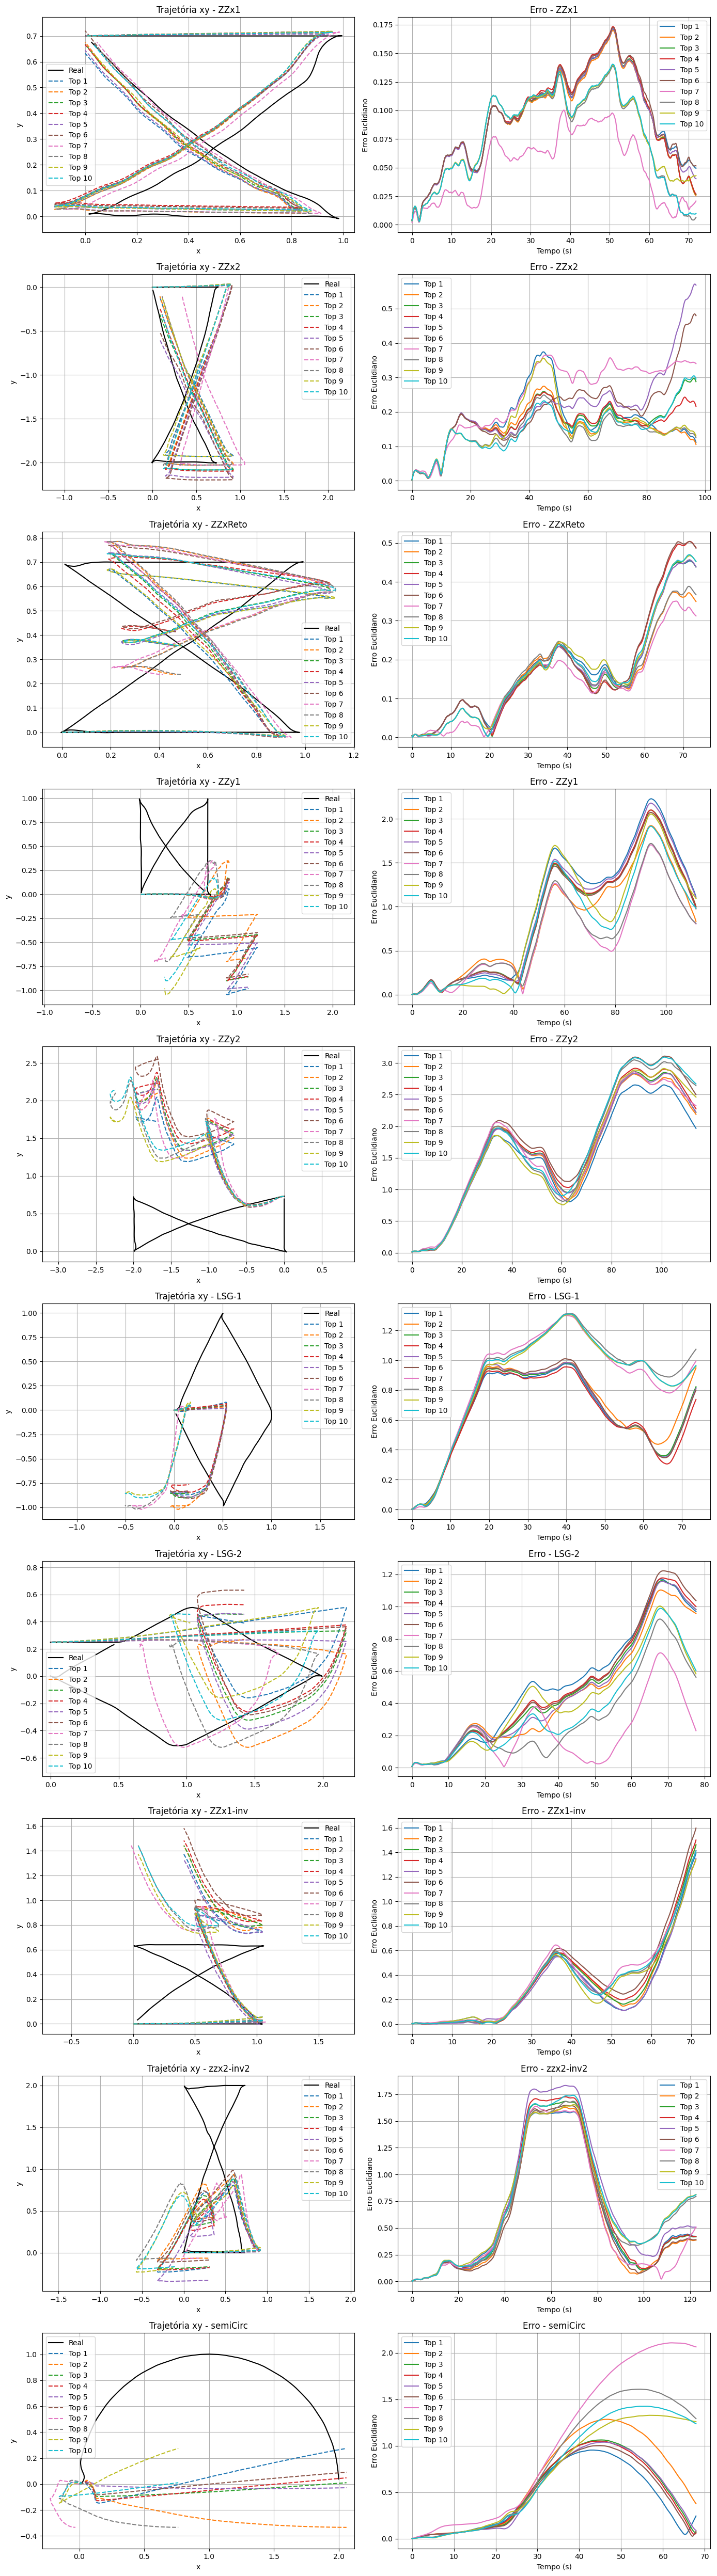

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

top3 = pd.read_excel("top3_combinacoes_gerais.xlsx")

n_rows = len(TITLES)

fig, axs = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))

# 🔹 garantir que axs sempre seja 2D
if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for idx, title in enumerate(TITLES):

    print(f"Plotando: {title}")

    dfx = df_x_all[title]
    dfy = df_y_all[title]

    x_real = dfx["x_real"].values
    y_real = dfy["y_real"].values

    ax_traj = axs[idx, 0]
    ax_erro = axs[idx, 1]

    # =========================
    # 🔹 Trajetória
    # =========================
    ax_traj.plot(x_real, y_real, 'k-', label="Real")

    for i in range(len(top3)):
        row = top3.iloc[i]
        col_x = row["x_model"]
        col_y = row["y_model"]

        x_pred = dfx[col_x].values
        y_pred = dfy[col_y].values

        min_len = min(len(x_real), len(x_pred), len(y_real), len(y_pred))

        xr = x_real[:min_len]
        yr = y_real[:min_len]
        xp = x_pred[:min_len]
        yp = y_pred[:min_len]

        ax_traj.plot(xp, yp, '--', label=f"Top {i+1}")

        # =========================
        # 🔹 Erro
        # =========================
        tempo = np.arange(min_len) * 0.07
        erro = np.sqrt((xr - xp)**2 + (yr - yp)**2)

        ax_erro.plot(tempo, erro, label=f"Top {i+1}")

    ax_traj.set_title(f"Trajetória xy - {title}")
    ax_traj.set_xlabel("x")
    ax_traj.set_ylabel("y")
    ax_traj.axis("equal")
    ax_traj.grid(True)
    ax_traj.legend()

    ax_erro.set_title(f"Erro - {title}")
    ax_erro.set_xlabel("Tempo (s)")
    ax_erro.set_ylabel("Erro Euclidiano")
    ax_erro.grid(True)
    ax_erro.legend()

plt.tight_layout()
plt.show()